In [1]:
import json
import warnings
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from catboost import Pool

warnings.filterwarnings("ignore")

SEED = 42
TARGET_COL = "readmitted_30d"
GROUP_COL = "desynpuf_id"

DATA_PATH = Path("../data/processed/model_dataset.csv")
MODEL_PATH = Path("../models/readmission_model.pkl")
METADATA_PATH = Path("../reports/metrics/model_metadata.json")
CV_RESULTS_PATH = Path("../reports/metrics/model_cv_results.csv")
HOLDOUT_METRICS_PATH = Path("../reports/metrics/holdout_metrics.csv")
HOLDOUT_PRED_PATH = Path("../reports/metrics/holdout_predictions.csv")

EXPLAIN_DIR = Path("../reports/figures/explainability")
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

MLRUNS_DIR = Path("../mlruns")
mlflow.set_tracking_uri(f"file:{MLRUNS_DIR.resolve()}")

model = joblib.load(MODEL_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

df = pd.read_csv(DATA_PATH)
cv_results = pd.read_csv(CV_RESULTS_PATH)
holdout_metrics = pd.read_csv(HOLDOUT_METRICS_PATH)
holdout_preds = pd.read_csv(HOLDOUT_PRED_PATH)

display(df.head())
display(cv_results)
display(holdout_metrics)
display(holdout_preds.head())

print("Best model:", metadata["best_model_name"])
print("Decision threshold:", metadata["decision_threshold"])
print("Categorical features:", len(metadata["categorical_features"]))
print("Numerical features:", len(metadata["numerical_features"]))

,desynpuf_id,readmitted_30d,length_of_stay,prior_admissions,days_since_last_admission,bene_sex_ident_cd,bene_race_cd,clm_utlztn_day_cnt,icd9_dgns_cd_1,icd9_dgns_cd_2,...,admissions_last_30d,admissions_last_90d,admissions_last_180d,age,diag_group,proc_group,comorbidity_count,primary_disease_group,primary_procedure_group,num_procedures
0,0001448457F2ED81,0,1,0,-1.0,2,2,0.0,9713.0,7580,...,0,0,0,32.988364,971,na,7,Other,NaN,0
1,0001448457F2ED81,0,1,1,-1.0,2,2,0.0,9713.0,7580,...,0,0,0,32.988364,971,na,7,Other,NaN,0
2,0001448457F2ED81,0,1,2,-1.0,2,2,0.0,9713.0,7580,...,0,0,0,32.988364,971,na,2,Other,NaN,0
3,0001448457F2ED81,0,12,3,60.0,2,2,12.0,29590.0,30390,...,0,3,3,33.155373,295,94,7,Other,Other,1
4,0001448457F2ED81,0,12,4,-12.0,2,2,12.0,29590.0,30390,...,0,3,3,33.155373,295,94,7,Other,Other,1


,Accuracy_Mean,Accuracy_SD,Precision_Mean,Precision_SD,Recall_Mean,Recall_SD,F1_Mean,F1_SD,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD,Model
0,0.966270,0.000204,0.983771,0.013487,0.225384,0.003254,0.366727,0.004391,0.894659,0.003961,0.406712,0.006147,CatBoost
1,0.965669,0.000179,0.945075,0.011495,0.220618,0.003515,0.357710,0.004673,0.888970,0.002688,0.395745,0.005587,LightGBM
2,0.725220,0.001272,0.129059,0.000613,0.929112,0.007195,0.226636,0.001097,0.885104,0.002428,0.389530,0.006614,XGBoost
3,0.717180,0.033828,0.093141,0.012517,0.624631,0.049773,0.161922,0.019914,0.749246,0.045368,0.132620,0.037050,Random Forest
4,0.798769,0.002687,0.063024,0.002844,0.262777,0.013213,0.101661,0.004636,0.580354,0.005586,0.058753,0.002372,Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.790149,0.149288,0.817552,0.252474,0.892288,0.393344


,desynpuf_id,y_true,y_prob,y_pred
0,0004D74110AB2B02,0,0.001625,0
1,0004D74110AB2B02,0,0.001925,0
2,0004D74110AB2B02,0,0.104070,1
3,0004D74110AB2B02,0,0.000260,0
4,0004D74110AB2B02,0,0.004643,0


Best model: CatBoost
Decision threshold: 0.08693263973821538
Categorical features: 34
Numerical features: 12


In [2]:
if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")
if GROUP_COL not in df.columns:
    raise ValueError(f"Missing group column: {GROUP_COL}")

df = df.dropna(subset=[TARGET_COL, GROUP_COL]).copy()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

X = df.drop(columns=[TARGET_COL, GROUP_COL]).copy()
y = df[TARGET_COL].copy()
groups = df[GROUP_COL].copy()

categorical_features = metadata["categorical_features"]
numerical_features = metadata["numerical_features"]

categorical_features = [c for c in categorical_features if c in X.columns]
numerical_features = [c for c in numerical_features if c in X.columns]

print(X.shape)
print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

(199783, 46)
Categorical: ['bene_sex_ident_cd', 'bene_race_cd', 'icd9_dgns_cd_1', 'icd9_dgns_cd_2', 'icd9_dgns_cd_3', 'icd9_dgns_cd_4', 'icd9_dgns_cd_5', 'icd9_dgns_cd_6', 'icd9_dgns_cd_7', 'icd9_dgns_cd_8', 'icd9_dgns_cd_9', 'icd9_dgns_cd_10', 'icd9_prcdr_cd_1', 'icd9_prcdr_cd_2', 'icd9_prcdr_cd_3', 'icd9_prcdr_cd_4', 'icd9_prcdr_cd_5', 'icd9_prcdr_cd_6', 'sp_state_code', 'sp_alzhdmta', 'sp_chf', 'sp_chrnkidn', 'sp_cncr', 'sp_copd', 'sp_depressn', 'sp_diabetes', 'sp_ischmcht', 'sp_osteoprs', 'sp_ra_oa', 'sp_strketia', 'diag_group', 'proc_group', 'primary_disease_group', 'primary_procedure_group']
Numerical: ['length_of_stay', 'prior_admissions', 'days_since_last_admission', 'clm_utlztn_day_cnt', 'admissions_last_7d', 'admissions_last_14d', 'admissions_last_30d', 'admissions_last_90d', 'admissions_last_180d', 'age', 'comorbidity_count', 'num_procedures']


In [3]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(cv.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True).copy()
X_test = X.iloc[test_idx].reset_index(drop=True).copy()
y_train = y.iloc[train_idx].reset_index(drop=True).copy()
y_test = y.iloc[test_idx].reset_index(drop=True).copy()
groups_test = groups.iloc[test_idx].reset_index(drop=True).copy()

print("Test rows:", len(X_test))
print("Test patients:", groups_test.nunique())
print("Test prevalence:")
print(y_test.value_counts(normalize=True).sort_index())

Test rows: 39957
Test patients: 7554
Test prevalence:
readmitted_30d
0    0.956653
1    0.043347
Name: proportion, dtype: float64


In [4]:
is_pipeline = hasattr(model, "named_steps")
model_name = metadata["best_model_name"]

print("Pipeline model:", is_pipeline)
print("Model name:", model_name)

if is_pipeline:
    preprocessor = model.named_steps["preprocessor"]
    estimator = model.named_steps["model"]
else:
    preprocessor = None
    estimator = model

Pipeline model: False
Model name: CatBoost


In [5]:
X_shap = X_test.sample(min(1000, len(X_test)), random_state=SEED).copy()

if model_name == "CatBoost":
    for col in categorical_features:
        if col in X_shap.columns:
            X_shap[col] = X_shap[col].astype("string").fillna("missing")

X_shap.head()

,length_of_stay,prior_admissions,days_since_last_admission,bene_sex_ident_cd,bene_race_cd,clm_utlztn_day_cnt,icd9_dgns_cd_1,icd9_dgns_cd_2,icd9_dgns_cd_3,icd9_dgns_cd_4,...,admissions_last_30d,admissions_last_90d,admissions_last_180d,age,diag_group,proc_group,comorbidity_count,primary_disease_group,primary_procedure_group,num_procedures
16408,16,7,-16.0,2,1,0.0,53642.0,29620,486,7863,...,0,3,6,75.337440,536,45,7,Other,Other,6
13681,8,1,-8.0,2,1,8.0,5849.0,7994,27800,V667,...,0,0,0,87.490760,584,39,7,Other,Other,1
9132,10,2,-10.0,1,1,10.0,389.0,78552,2761,496,...,0,0,0,100.271047,038,96,4,Other,Other,5
27291,12,8,-12.0,1,1,12.0,39891.0,40390,5859,4241,...,0,3,3,76.848734,398,88,5,Other,Other,5
26271,1,2,-1.0,1,1,1.0,42731.0,41400,42781,4280,...,0,0,0,83.334702,427,99,2,Other,Other,1


In [6]:
def save_fig(name: str):
    path = EXPLAIN_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")

if is_pipeline and model_name != "CatBoost":
    X_trans = preprocessor.transform(X_shap)
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()

    if model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(estimator, X_trans, feature_names=feature_names)
        shap_values = explainer(X_trans)
    else:
        explainer = shap.Explainer(estimator, X_trans, feature_names=feature_names)
        shap_values = explainer(X_trans)

    shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=False)
    save_fig("shap_summary_pipeline.png")
    plt.show()

    shap.plots.bar(shap_values, max_display=20, show=False)
    save_fig("shap_bar_pipeline.png")
    plt.show()

Saved: ..\reports\figures\explainability\shap_summary_catboost.png


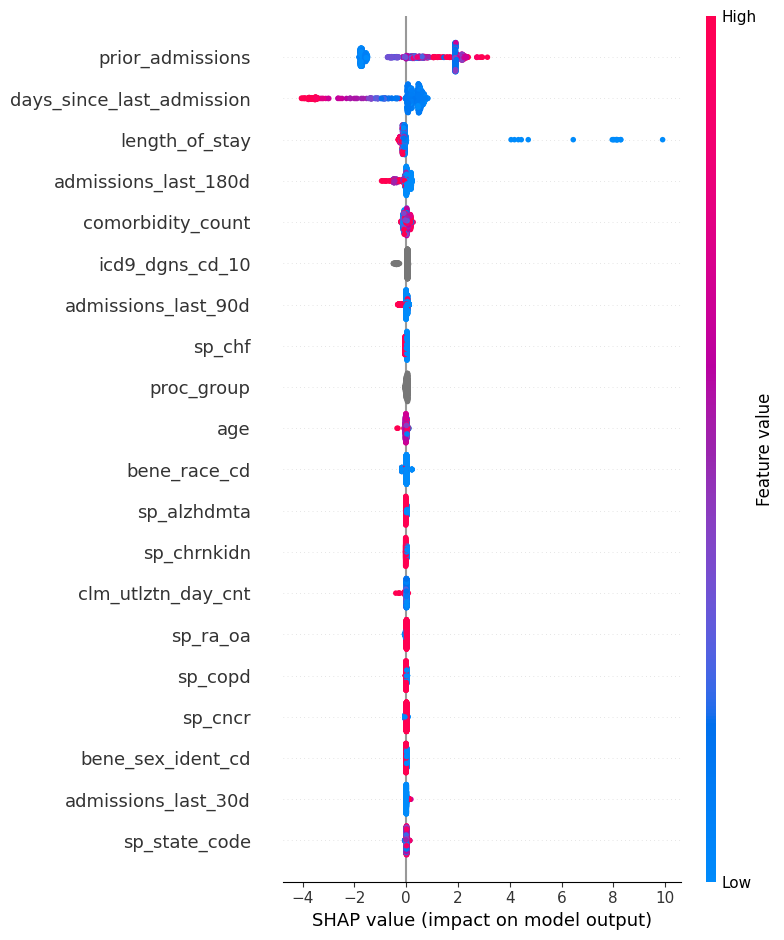

,feature,mean_abs_shap
1,prior_admissions,1.469677
2,days_since_last_admission,0.639501
0,length_of_stay,0.208903
38,admissions_last_180d,0.126869
42,comorbidity_count,0.073708
15,icd9_dgns_cd_10,0.064573
37,admissions_last_90d,0.042602
24,sp_chf,0.029557
41,proc_group,0.024604
39,age,0.022173


Saved: ..\reports\figures\explainability\shap_bar_catboost.png


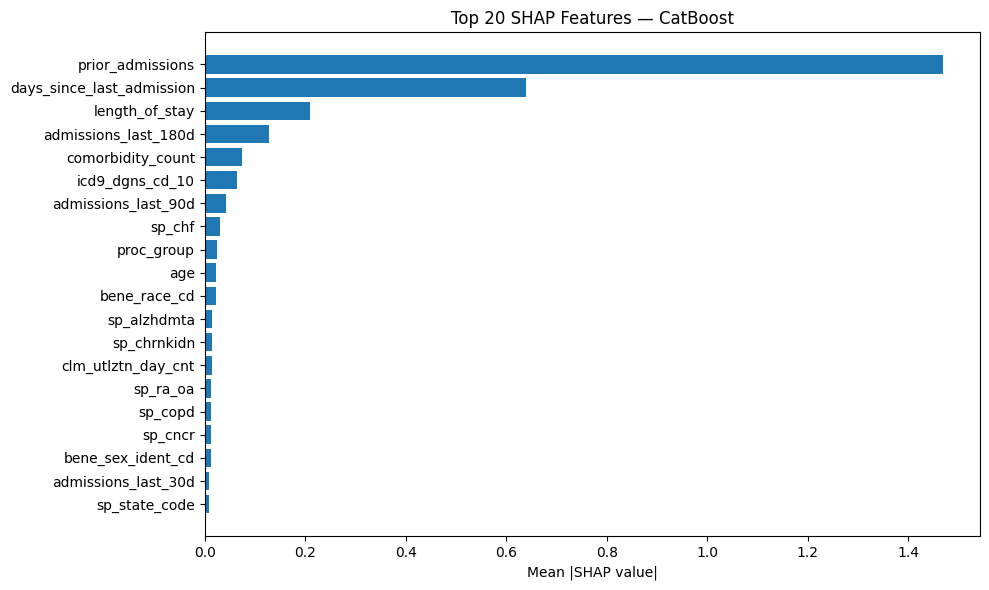

In [7]:
if model_name == "CatBoost":
    cat_pool = Pool(X_shap, cat_features=categorical_features)
    shap_matrix = model.get_feature_importance(cat_pool, type="ShapValues")

    shap_values = shap_matrix[:, :-1]
    base_values = shap_matrix[:, -1]
    feature_names = X_shap.columns.tolist()

    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
    save_fig("shap_summary_catboost.png")
    plt.show()

    mean_abs_shap = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    display(mean_abs_shap.head(20))

    plt.figure(figsize=(10, 6))
    top = mean_abs_shap.head(20).iloc[::-1]
    plt.barh(top["feature"], top["mean_abs_shap"])
    plt.title("Top 20 SHAP Features — CatBoost")
    plt.xlabel("Mean |SHAP value|")
    save_fig("shap_bar_catboost.png")
    plt.show()

In [8]:
if model_name == "CatBoost":
    importance_df = pd.DataFrame({
        "feature": X_shap.columns.tolist(),
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
else:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values.values if hasattr(shap_values, "values") else shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

importance_df.to_csv(EXPLAIN_DIR / "global_shap_importance.csv", index=False)
display(importance_df.head(20))

,feature,mean_abs_shap
1,prior_admissions,1.469677
2,days_since_last_admission,0.639501
0,length_of_stay,0.208903
38,admissions_last_180d,0.126869
42,comorbidity_count,0.073708
15,icd9_dgns_cd_10,0.064573
37,admissions_last_90d,0.042602
24,sp_chf,0.029557
41,proc_group,0.024604
39,age,0.022173


In [9]:
decision_threshold = metadata["decision_threshold"]

if is_pipeline:
    holdout_prob = model.predict_proba(X_test)[:, 1]
else:
    X_test_cb = X_test.copy()
    for col in categorical_features:
        if col in X_test_cb.columns:
            X_test_cb[col] = X_test_cb[col].astype("string").fillna("missing")
    holdout_prob = model.predict_proba(X_test_cb)[:, 1]

holdout_pred = (holdout_prob >= decision_threshold).astype(int)

analysis_df = X_test.copy()
analysis_df["y_true"] = y_test.values
analysis_df["y_prob"] = holdout_prob
analysis_df["y_pred"] = holdout_pred

analysis_df["case_type"] = np.select(
    [
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 1),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1),
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 0),
    ],
    ["True Positive", "False Positive", "False Negative", "True Negative"],
    default="Other"
)

display(analysis_df["case_type"].value_counts())

case_type
True Negative     31463
False Positive     6762
True Positive      1289
False Negative      443
Name: count, dtype: int64

Saved: ..\reports\figures\explainability\waterfall_true_positive.png


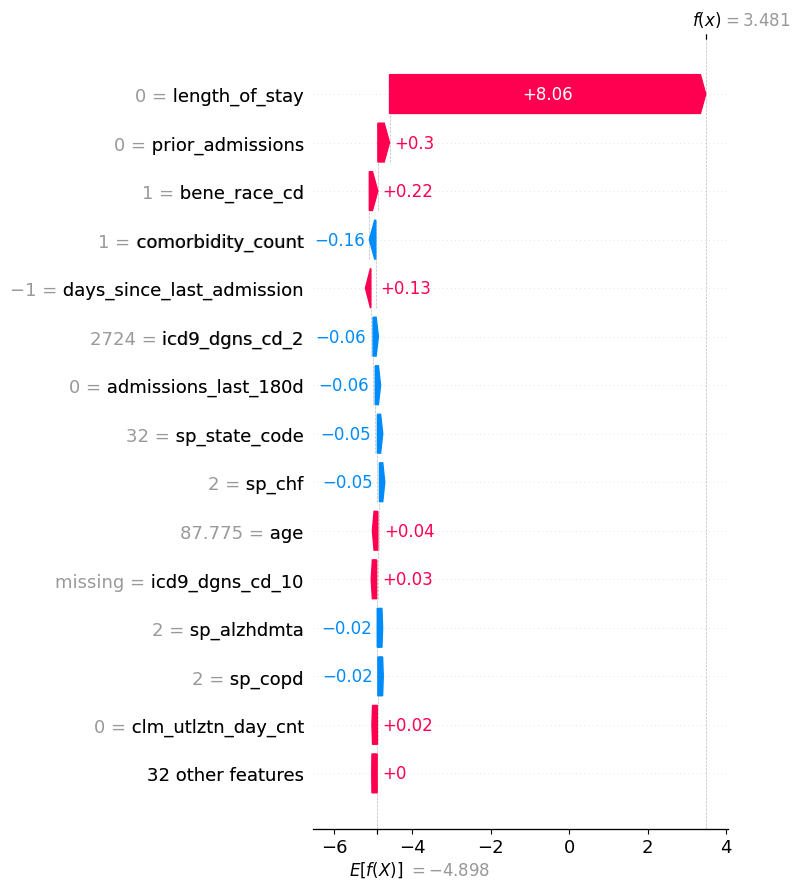

Saved: ..\reports\figures\explainability\waterfall_false_positive.png


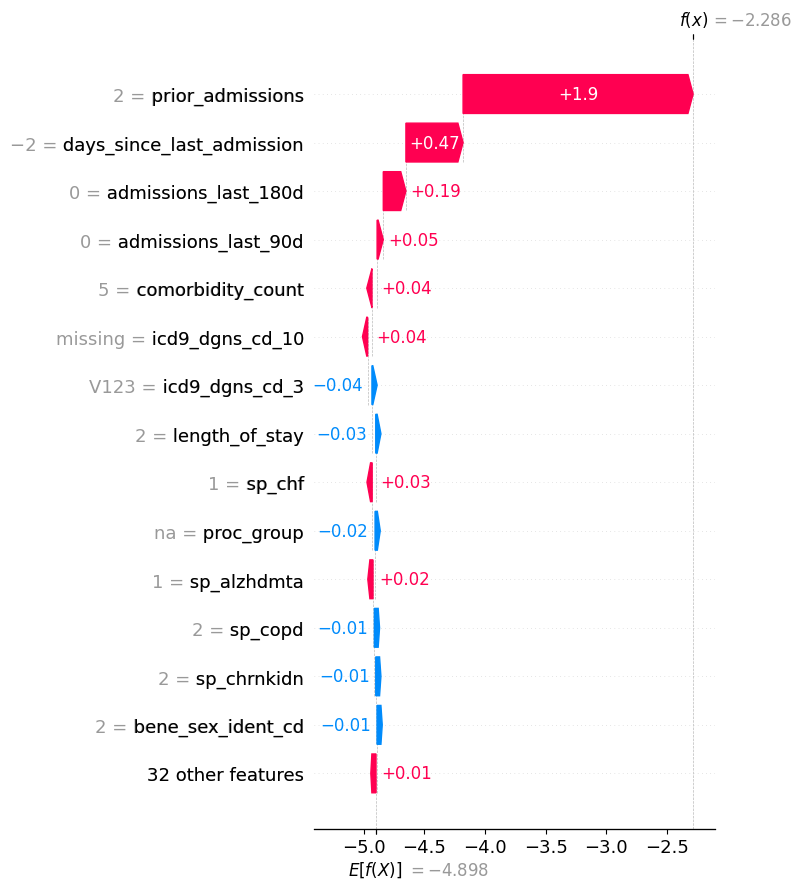

Saved: ..\reports\figures\explainability\waterfall_false_negative.png


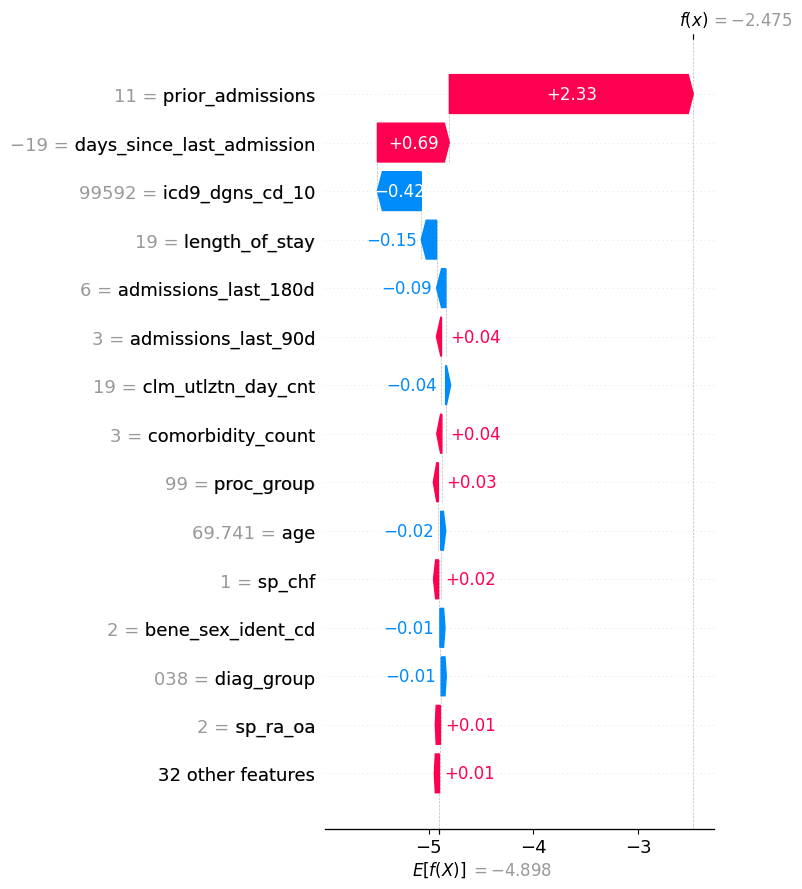

Saved: ..\reports\figures\explainability\waterfall_true_negative.png


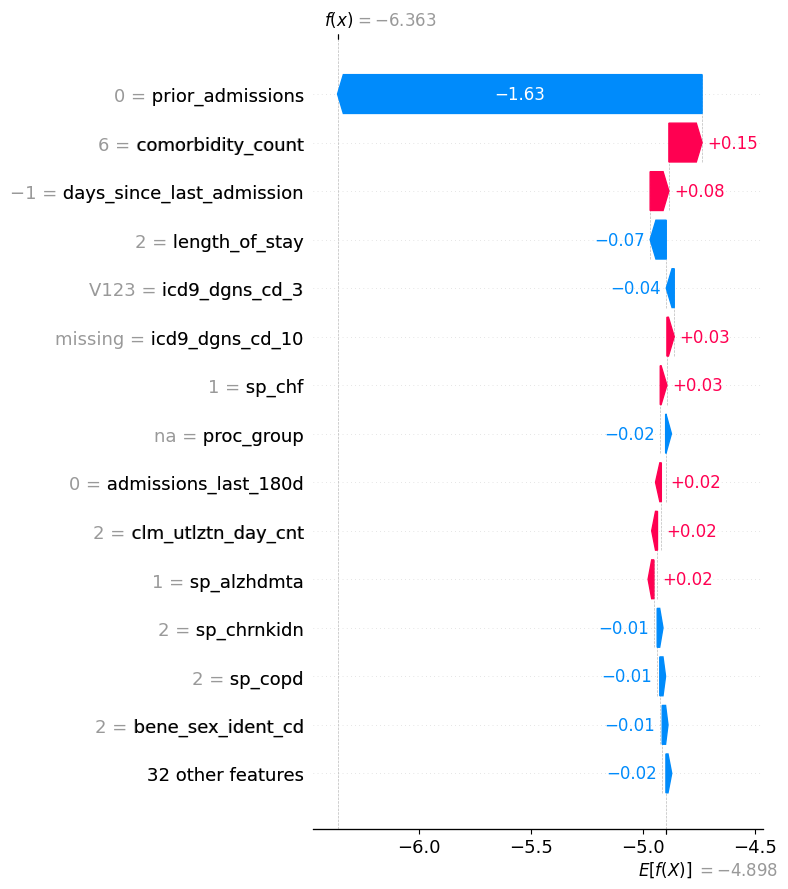

In [10]:
def explain_single_row(row_df: pd.DataFrame, label: str):
    if model_name == "CatBoost":
        row = row_df.copy()
        for col in categorical_features:
            if col in row.columns:
                row[col] = row[col].astype("string").fillna("missing")
        pool = Pool(row, cat_features=categorical_features)
        sv = model.get_feature_importance(pool, type="ShapValues")
        values = sv[:, :-1]
        base = sv[:, -1][0]
        explanation = shap.Explanation(
            values=values[0],
            base_values=base,
            data=row.iloc[0].values,
            feature_names=row.columns.tolist(),
        )
        shap.plots.waterfall(explanation, max_display=15, show=False)
        save_fig(f"waterfall_{label.replace(' ', '_').lower()}.png")
        plt.show()

    else:
        x_trans = preprocessor.transform(row_df)
        if hasattr(x_trans, "toarray"):
            x_trans = x_trans.toarray()
        feature_names = preprocessor.get_feature_names_out()

        if model_name == "Logistic Regression":
            explainer = shap.LinearExplainer(estimator, x_trans, feature_names=feature_names)
            sv = explainer(x_trans)
        else:
            explainer = shap.Explainer(estimator, x_trans, feature_names=feature_names)
            sv = explainer(x_trans)

        shap.plots.waterfall(sv[0], max_display=15, show=False)
        save_fig(f"waterfall_{label.replace(' ', '_').lower()}.png")
        plt.show()

for case in ["True Positive", "False Positive", "False Negative", "True Negative"]:
    sample = analysis_df[analysis_df["case_type"] == case].head(1)
    if len(sample) == 0:
        continue
    explain_single_row(sample.drop(columns=["y_true", "y_prob", "y_pred", "case_type"]), case)

In [11]:
top_features = importance_df["feature"].head(3).tolist()
print(top_features)

if model_name != "CatBoost" and is_pipeline:
    for feat in top_features:
        shap.plots.scatter(shap_values[:, feat], color=shap_values, show=False)
        save_fig(f"dependence_{feat.replace(' ', '_').lower()}.png")
        plt.show()

['prior_admissions', 'days_since_last_admission', 'length_of_stay']


In [12]:
error_df = analysis_df[["y_true", "y_pred", "y_prob"]].copy()
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
    ],
    ["False Negative", "False Positive"],
    default="Correct"
)

display(error_df["error_type"].value_counts())

print("Accuracy:", accuracy_score(error_df["y_true"], error_df["y_pred"]))
print("Precision:", precision_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
print("Recall:", recall_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
print("F1:", f1_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
print("ROC-AUC:", roc_auc_score(error_df["y_true"], error_df["y_prob"]))
print("PR-AUC:", average_precision_score(error_df["y_true"], error_df["y_prob"]))

error_type
Correct           32752
False Positive     6762
False Negative      443
Name: count, dtype: int64

Accuracy: 0.8196811572440373
Precision: 0.16010433486523412
Recall: 0.7442263279445728
F1: 0.26351834815496267
ROC-AUC: 0.8928698737419889
PR-AUC: 0.39694789355837107


In [13]:
mlflow.set_experiment("cms_readmission_explainability")

<Experiment: artifact_location='file:C:\\Users\\ohriv\\Downloads\\clinical-outcome-prediction\\mlruns/392709365937657293', creation_time=1783003910514, experiment_id='392709365937657293', last_update_time=1783003910514, lifecycle_stage='active', name='cms_readmission_explainability', tags={}, trace_location=None, workspace='default'>

In [14]:
with mlflow.start_run(run_name=f"explain_{metadata['best_model_name']}"):
    mlflow.log_param("model_name", metadata["best_model_name"])
    mlflow.log_param("decision_threshold", metadata["decision_threshold"])
    mlflow.log_param("target_col", metadata["target"])
    mlflow.log_param("group_col", metadata["group_col"])
    mlflow.log_param("num_categorical_features", len(categorical_features))
    mlflow.log_param("num_numerical_features", len(numerical_features))
    mlflow.log_param("shap_sample_size", len(X_shap))

    if "PR_AUC_Mean" in cv_results.columns:
        mlflow.log_metric("cv_pr_auc_mean", float(cv_results["PR_AUC_Mean"].iloc[0]))
    if "ROC_AUC_Mean" in cv_results.columns:
        mlflow.log_metric("cv_roc_auc_mean", float(cv_results["ROC_AUC_Mean"].iloc[0]))

    mlflow.log_metric("holdout_accuracy", accuracy_score(error_df["y_true"], error_df["y_pred"]))
    mlflow.log_metric("holdout_precision", precision_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
    mlflow.log_metric("holdout_recall", recall_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
    mlflow.log_metric("holdout_f1", f1_score(error_df["y_true"], error_df["y_pred"], zero_division=0))
    mlflow.log_metric("holdout_roc_auc", roc_auc_score(error_df["y_true"], error_df["y_prob"]))
    mlflow.log_metric("holdout_pr_auc", average_precision_score(error_df["y_true"], error_df["y_prob"]))

    mlflow.log_artifact(str(METADATA_PATH))
    mlflow.log_artifact(str(CV_RESULTS_PATH))
    mlflow.log_artifact(str(HOLDOUT_METRICS_PATH))
    mlflow.log_artifact(str(HOLDOUT_PRED_PATH))
    mlflow.log_artifact(str(EXPLAIN_DIR / "global_shap_importance.csv"))

    for fig_name in EXPLAIN_DIR.glob("*.png"):
        mlflow.log_artifact(str(fig_name))

    if is_pipeline:
        mlflow.sklearn.log_model(model, artifact_path="model")